In [1]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
conn=mysql.connector.connect(
        host="localhost",
        user="root",
        password="",             
        database="online_learning_experience_survey"
    )

In [3]:
query="SELECT * FROM response"
survey=pd.read_sql(query,conn)
conn.close()

C:\Users\admin\AppData\Local\Temp\ipykernel_9880\3083696678.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  survey=pd.read_sql(query,conn)


In [4]:
survey.head(5)

,id,response_id,poll_option,educational_level,Gender,Age_group,Device,timestamp
0,1,RESP_1,Average,College Student,MALE,19-25,laptop,2026-02-24 12:58:20
1,2,RESP_1,Average,College Student,FEMALE,19-25,mobile,2026-02-27 11:37:55
2,3,RESP_2,Excellent,School Student,Others,15-18,tablet,2026-02-27 11:38:10
3,4,RESP_3,Excellent,Others,MALE,above40,desktop,2026-02-27 11:38:29
4,5,RESP_4,Excellent,School Student,FEMALE,26-40,laptop,2026-02-27 11:38:44


In [5]:
survey.shape

(48, 8)

In [6]:
count_poll_option=survey.groupby("poll_option")["response_id"].count()
count_poll_option

poll_option
Average      14
Excellent    14
Good         12
Poor          8
Name: response_id, dtype: int64

In [7]:
percentage_distribution=survey["poll_option"].value_counts(normalize=True)*100
percentage_distribution

poll_option
Average      29.166667
Excellent    29.166667
Good         25.000000
Poor         16.666667
Name: proportion, dtype: float64

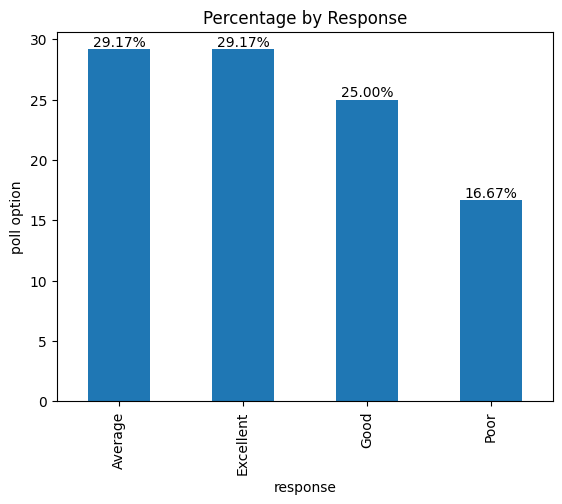

In [8]:
plt.figure()

percentage_distribution.plot(kind="bar")
plt.xlabel("response")
plt.ylabel("poll option")
plt.title("Percentage by Response")
for i,value in enumerate(percentage_distribution.values):
    plt.text(i,value,f'{value:.2f}%',ha='center',va='bottom')

plt.show()

In [9]:
survey["poll_option"].value_counts().idxmax()

'Average'

In [10]:
count_education=survey.groupby("educational_level")["response_id"].count()
count_education

educational_level
College Student         19
Others                   9
School Student           9
Working Professional    11
Name: response_id, dtype: int64

In [11]:
percentage_education=survey["educational_level"].value_counts(normalize=True)*100
percentage_education

educational_level
College Student         39.583333
Working Professional    22.916667
School Student          18.750000
Others                  18.750000
Name: proportion, dtype: float64

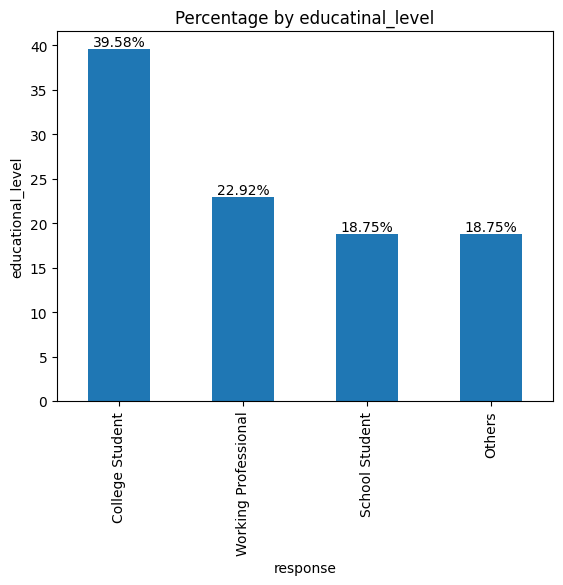

In [12]:
plt.figure()

percentage_education.plot(kind="bar")
plt.xlabel("response")
plt.ylabel("educational_level")
plt.title("Percentage by educatinal_level")
for i,value in enumerate(percentage_education.values):
    plt.text(i,value,f'{value:.2f}%',ha='center',va='bottom')

plt.show()

In [13]:
count_device=survey.groupby("Device")["response_id"].count()
count_device

Device
desktop     9
laptop     21
mobile     10
tablet      8
Name: response_id, dtype: int64

In [14]:
percentage_device=survey["Device"].value_counts(normalize=True)*100
percentage_device

Device
laptop     43.750000
mobile     20.833333
desktop    18.750000
tablet     16.666667
Name: proportion, dtype: float64

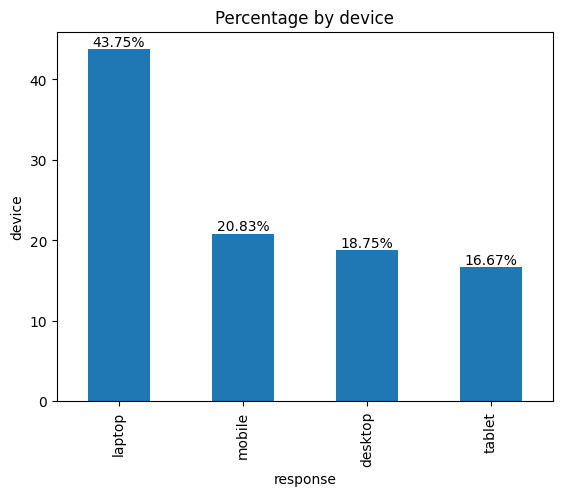

In [15]:
plt.figure()

percentage_device.plot(kind="bar")
plt.xlabel("response")
plt.ylabel("device")
plt.title("Percentage by device")
for i,value in enumerate(percentage_device.values):
    plt.text(i,value,f'{value:.2f}%',ha='center',va='bottom')

plt.show()

In [16]:

count_gender=survey.groupby("Gender")["response_id"].count()
count_gender

Gender
           1
FEMALE    15
MALE      26
Others     6
Name: response_id, dtype: int64

In [17]:
percentage_gender=survey["Gender"].value_counts(normalize=True)*100
percentage_gender

Gender
MALE      54.166667
FEMALE    31.250000
Others    12.500000
           2.083333
Name: proportion, dtype: float64

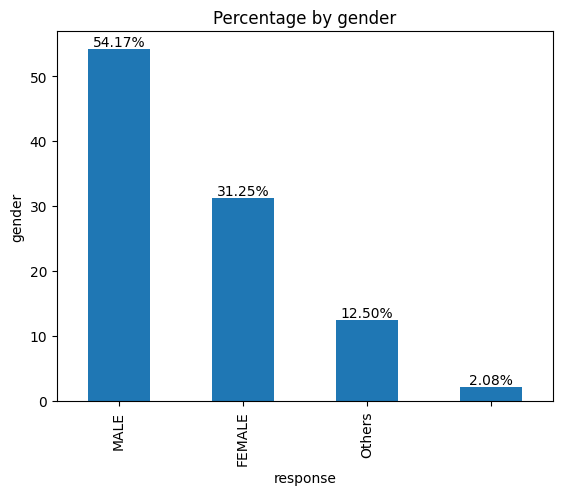

In [18]:
plt.figure()

percentage_gender.plot(kind="bar")
plt.xlabel("response")
plt.ylabel("gender")
plt.title("Percentage by gender")
for i,value in enumerate(percentage_gender.values):
    plt.text(i,value,f'{value:.2f}%',ha='center',va='bottom')

plt.show()

In [19]:
survey["poll_option"].value_counts().idxmin()

'Poor'

In [20]:
survey["timestamp"]=pd.to_datetime(survey['timestamp'])
survey.groupby(survey["timestamp"].dt.date).size()

timestamp
2026-02-24     1
2026-02-27    20
2026-03-02     9
2026-03-04    11
2026-03-09     1
2026-03-10     5
2026-03-11     1
dtype: int64

In [21]:
group_based=pd.crosstab(survey["educational_level"],survey["poll_option"])
group_based

poll_option,Average,Excellent,Good,Poor
educational_level,,,,
College Student,9,3,6,1
Others,1,4,1,3
School Student,1,6,0,2
Working Professional,3,1,5,2


In [22]:
survey.to_csv("survey.csv")